In [1]:
import pandas as pd

df = pd.read_csv("nba_shot_data_cleaned.csv")

## Select the features to form a new table.

In [2]:
player_stats = df.groupby(["PLAYER_ID", "PLAYER_NAME"]).agg(
    FGA=("SHOT_MADE_FLAG", "count"),              # Shots attempted
    FG_pct=("SHOT_MADE_FLAG", "mean"),            # Accuracy Rate
    Avg_Distance=("shotDistance", "mean"),        # Average distance
    Median_Distance=("shotDistance", "median")    # Median distance
).reset_index()

In [3]:
shot_type_dist = (
    df.groupby(["PLAYER_ID", "SHOT_TYPE"])["SHOT_MADE_FLAG"]
    .count()
    .unstack(fill_value=0)    
)

In [4]:
shot_type_dist["Total"] = shot_type_dist.sum(axis=1)
shot_type_dist["2PT_pct"] = shot_type_dist.get("2PT Field Goal", 0) / shot_type_dist["Total"]
shot_type_dist["3PT_pct"] = shot_type_dist.get("3PT Field Goal", 0) / shot_type_dist["Total"]
shot_type_dist = shot_type_dist[["2PT_pct", "3PT_pct"]]

In [5]:
zone_dist = (
    df.groupby(["PLAYER_ID", "SHOT_ZONE_BASIC"])["SHOT_MADE_FLAG"]
    .count()
    .unstack(fill_value=0)
)
zone_dist = zone_dist.div(zone_dist.sum(axis=1), axis=0)

In [6]:
player_features = (
    player_stats.set_index("PLAYER_ID")
    .join(shot_type_dist)   
    .join(zone_dist)        
    .reset_index()
)

In [7]:
player_features.head()



,PLAYER_ID,PLAYER_NAME,FGA,FG_pct,Avg_Distance,Median_Distance,2PT_pct,3PT_pct,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3
0,2544,LeBron James,1270,0.512598,13.432362,11.780,0.688189,0.311811,0.281102,0.001575,0.212598,0.018110,0.171654,0.303937,0.011024
1,101108,Chris Paul,583,0.427101,21.200772,24.790,0.363636,0.636364,0.548885,0.003431,0.111492,0.041166,0.222985,0.029160,0.042882
2,200768,Kyle Lowry,117,0.350427,22.457521,25.070,0.247863,0.752137,0.564103,0.017094,0.119658,0.085470,0.076923,0.051282,0.085470
3,200782,P.J. Tucker,7,0.428571,23.851429,23.160,0.142857,0.857143,0.142857,0.000000,0.000000,0.428571,0.142857,0.000000,0.285714
4,201142,Kevin Durant,1124,0.526690,15.451210,14.335,0.669039,0.330961,0.252669,0.000000,0.304270,0.037367,0.254448,0.110320,0.040925


## Perform K-Means clustering to divide players into three categories: Cluster 0: Low-post scorers Cluster 1: Mid-range shooters Cluster 2: Three-point shooters

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = player_features.drop(columns=["PLAYER_ID","PLAYER_NAME","FGA"])
X = features.fillna(0)   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)  
clusters = kmeans.fit_predict(X_scaled)

player_features["Cluster"] = clusters
player_features.head()

c:\Users\carls\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\carls\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\carls\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\carls\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
      

,PLAYER_ID,PLAYER_NAME,FGA,FG_pct,Avg_Distance,Median_Distance,2PT_pct,3PT_pct,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3,Cluster
0,2544,LeBron James,1270,0.512598,13.432362,11.780,0.688189,0.311811,0.281102,0.001575,0.212598,0.018110,0.171654,0.303937,0.011024,1
1,101108,Chris Paul,583,0.427101,21.200772,24.790,0.363636,0.636364,0.548885,0.003431,0.111492,0.041166,0.222985,0.029160,0.042882,2
2,200768,Kyle Lowry,117,0.350427,22.457521,25.070,0.247863,0.752137,0.564103,0.017094,0.119658,0.085470,0.076923,0.051282,0.085470,2
3,200782,P.J. Tucker,7,0.428571,23.851429,23.160,0.142857,0.857143,0.142857,0.000000,0.000000,0.428571,0.142857,0.000000,0.285714,2
4,201142,Kevin Durant,1124,0.526690,15.451210,14.335,0.669039,0.330961,0.252669,0.000000,0.304270,0.037367,0.254448,0.110320,0.040925,1


c:\Users\carls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [9]:
num_cols = player_features.select_dtypes(include="number").columns
cluster_profiles = player_features.groupby("Cluster")[num_cols].mean()
print(cluster_profiles[["2PT_pct","3PT_pct","Avg_Distance","FG_pct"]])

          2PT_pct   3PT_pct  Avg_Distance    FG_pct
Cluster                                            
0        0.914487  0.085513      5.676850  0.581527
1        0.623366  0.376634     13.523745  0.433824
2        0.371257  0.628743     18.561118  0.408683


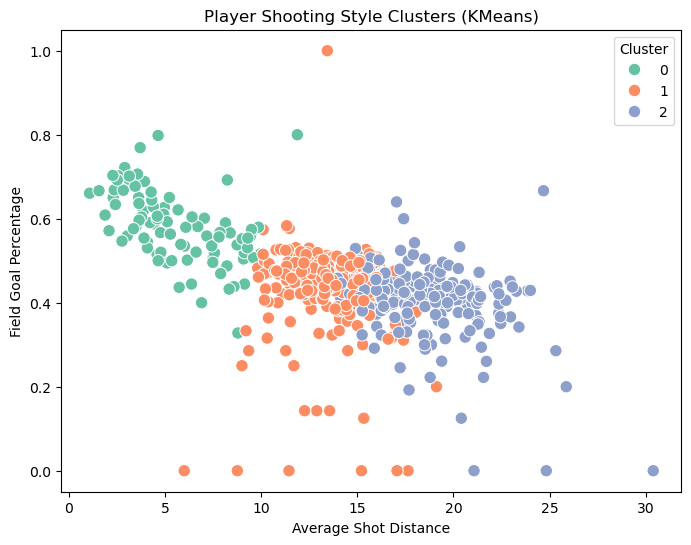

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=player_features,
    x="Avg_Distance",    
    y="FG_pct",            
    hue="Cluster",         
    palette="Set2", s=80
)
plt.title("Player Shooting Style Clusters (KMeans)")
plt.xlabel("Average Shot Distance")
plt.ylabel("Field Goal Percentage")
plt.legend(title="Cluster", loc="best")
plt.show()

## Select three representative figures from each category.

In [29]:
rep_players = (
    player_features.groupby("Cluster")
    .apply(lambda g: g.sort_values("FGA", ascending=False).head(3)[["PLAYER_NAME","FGA","FG_pct"]])
)
print(rep_players)

                         PLAYER_NAME   FGA    FG_pct
Cluster                                             
0       53     Giannis Antetokounmpo  1319  0.601213
        325           Alperen Sengun  1143  0.496063
        116              Ivica Zubac   942  0.628450
1       161  Shai Gilgeous-Alexander  1656  0.519324
        333          Cade Cunningham  1457  0.469458
        270              Jalen Green  1437  0.423104
2       238          Anthony Edwards  1612  0.447270
        124             Jayson Tatum  1465  0.451877
        14              James Harden  1295  0.410039


C:\Users\carls\AppData\Local\Temp\ipykernel_31276\1381673417.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("FGA", ascending=False).head(3)[["PLAYER_NAME","FGA","FG_pct"]])


## Gaussian Mixture Model (GMM)

In [18]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42, covariance_type="tied")
player_features["Cluster_GMM"] = gmm.fit_predict(X_scaled)
print(player_features[["PLAYER_NAME", "FG_pct", "Avg_Distance", "Cluster_GMM"]].head())


    PLAYER_NAME    FG_pct  Avg_Distance  Cluster_GMM
0  LeBron James  0.512598     13.432362            1
1    Chris Paul  0.427101     21.200772            2
2    Kyle Lowry  0.350427     22.457521            2
3   P.J. Tucker  0.428571     23.851429            2
4  Kevin Durant  0.526690     15.451210            1


c:\Users\carls\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [22]:
cluster_summary = player_features.groupby("Cluster_GMM")[features.columns].mean()

print(cluster_summary.round(3))


             FG_pct  Avg_Distance  Median_Distance  2PT_pct  3PT_pct  \
Cluster_GMM                                                            
0             0.610         4.275            2.566    0.961    0.039   
1             0.442        12.679            9.556    0.658    0.342   
2             0.414        18.178           22.899    0.392    0.608   

             Above the Break 3  Backcourt  In The Paint (Non-RA)  \
Cluster_GMM                                                        
0                        0.024      0.001                  0.254   
1                        0.239      0.002                  0.250   
2                        0.423      0.003                  0.133   

             Left Corner 3  Mid-Range  Restricted Area  Right Corner 3  
Cluster_GMM                                                             
0                    0.008      0.030            0.676           0.006  
1                    0.051      0.091            0.317           0.050  
2     

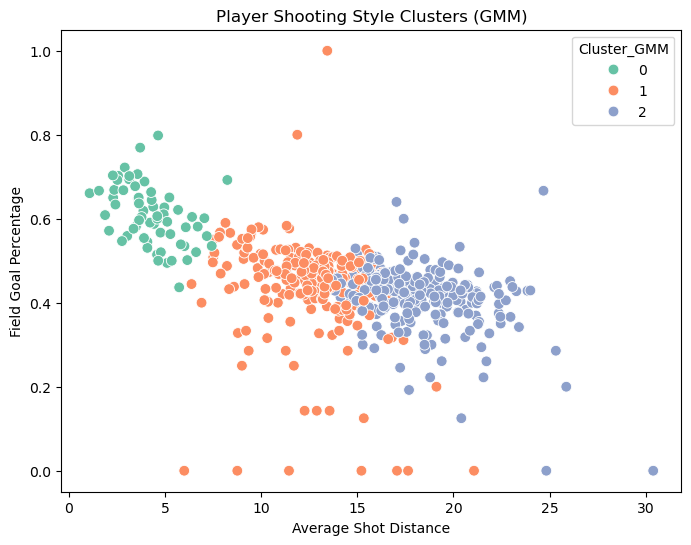

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=player_features,
    x="Avg_Distance", y="FG_pct",
    hue="Cluster_GMM", palette="Set2", s=60
)
plt.title("Player Shooting Style Clusters (GMM)")
plt.xlabel("Average Shot Distance")
plt.ylabel("Field Goal Percentage")
plt.show()